In [1]:
import pandas as pd

df = pd.read_csv("../data/exploration.csv")

We use codebert-base to vectorize the code which gives relatively few dimensions(768) and leverages code patterns learned from a larger corpus than ours

In [ ]:
from tqdm import tqdm
tqdm.pandas()
import sys
sys.path.append("..")

from python_editor.data_processing import vectorize_code, split_by_developer

df["embedding"] = df.progress_apply(vectorize_code, axis=1)

100%|██████████| 2/2 [00:07<00:00,  3.91s/it]


We add embeddings to our df and save it for easy loading later

In [ ]:
df = df.reset_index(drop=True)
df.to_pickle("../data/embeddings.pkl")

Split dataset

In [4]:
train, test = split_by_developer(df, test_size=0.3, random_state=0)

UMAP helps us visualize the 768 dimensions by reducing them to only 2

In [8]:
import umap

umap_embedder = umap.UMAP()
umap_emb = umap_embedder.fit_transform(train["embedding"].to_list())

We can see three main chunks where the middle small one has mainly low score

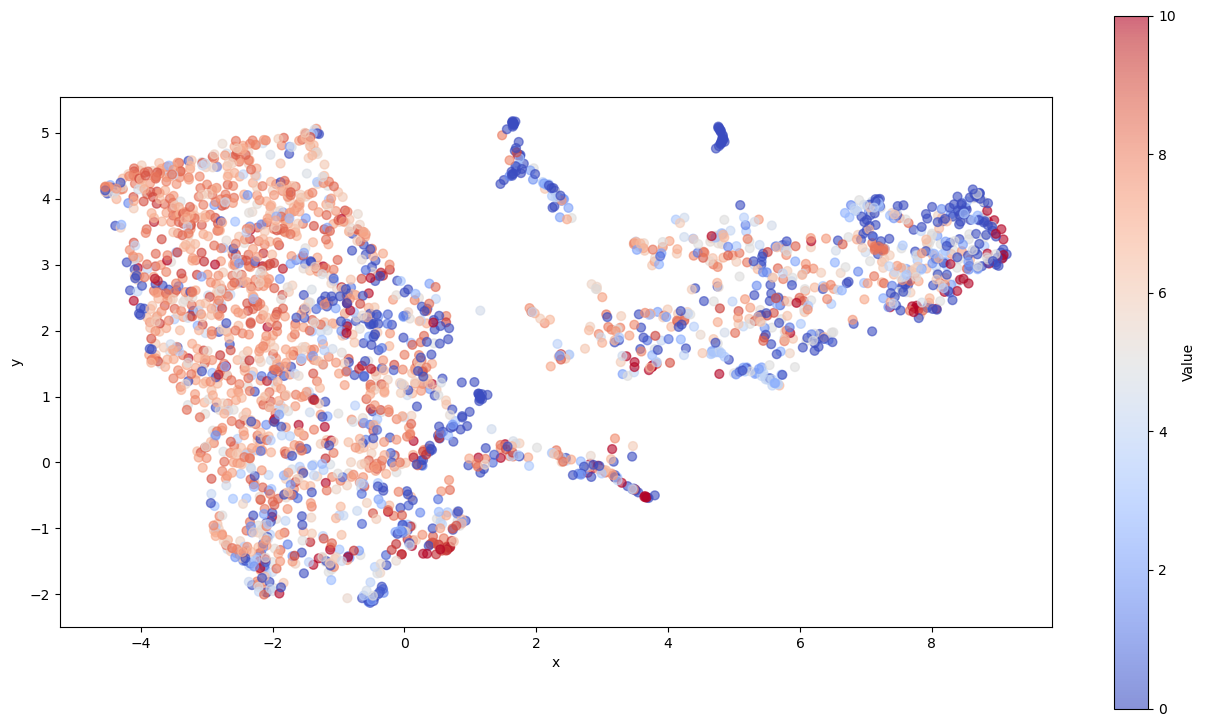

In [9]:
from python_editor.data_visualization import plot_embeddings

plot_embeddings(umap_emb, train["pylint_score"])